In [1]:
import sys

sys.path.insert(0, '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib')
print(sys.path)

['/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib', '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/autoencoder', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python312.zip', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/lib-dynload', '', '/home/amunif/.local/lib/python3.12/site-packages', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages']


In [2]:
import os
import random
from datetime import datetime

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import BinaryClassifier as BC
import HepG2Dataset as HG2D
import my_util
import AutoEncoder as AE

In [3]:
# Declare  variables, working directory and dataset directory
MODE = 'all_features'
NUM_EPOCHS = 200
START_EPOCH = 0
NUM_ITEMS = 100_000
BATCH_SIZE = 64
DROPOUT_RATE = 0.2

L1_lambda = 0.005
L2_lambda = 0.001
# L1_lambda = 0.0
# L2_lambda = 0.0

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

MODEL_MODE = "dol1l2" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-autoencoder-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}-{L1_lambda}-{L2_lambda}"

CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'model', f'{PREFIX}-checkpoint-{SUFFIX}.pt')

IMAGE_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'img', 'train', f"{PREFIX}-ranking-{SUFFIX}.png")
TEST_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'test', f"{PREFIX}-test-results-{SUFFIX}.txt")
TRAINING_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, "train", f"{PREFIX}-train-validation-metrics-{SUFFIX}.csv")
TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, "test", f"{PREFIX}-test-metrics-{SUFFIX}.csv")
ROC_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'img', 'roc', f"{PREFIX}-roc-{SUFFIX}.png")
CM_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'img', 'cm', f"{PREFIX}-cm-{SUFFIX}.png")

INPUT_SIZE = 200

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/autoencoder/all_features/model/dol1l2-autoencoder-0.2-checkpoint-100000-200-64-0.005-0.001.pt


In [4]:
device = my_util.get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [5]:
# Load dataset
all_features = pl.read_parquet(os.path.join(DATASET_DIR, 'features', f'{MODE}.parquet'))
all_features

index,gene_id,all_features,value_1
u32,str,list[f64],f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [6]:
all_features_np = all_features.to_numpy()
all_features_np

array([[0, 'XLOC_000001', array([0., 0., 0., ..., 0., 0., 0.]), 0.0],
       [1, 'XLOC_000003', array([0., 0., 0., ..., 0., 0., 0.]), 0.0],
       [2, 'XLOC_000006', array([0., 0., 0., ..., 0., 0., 0.]),
        0.0888452],
       ...,
       [22151, 'XLOC_030014', array([0., 0., 0., ..., 0., 0., 0.]), 0.0],
       [22152, 'XLOC_030017', array([0., 0., 0., ..., 0., 0., 0.]), 0.0],
       [22153, 'XLOC_030018', array([0., 0., 0., ..., 0., 0., 0.]), 0.0]],
      dtype=object)

In [7]:
X_col = all_features_np[:, 2]
y_col = all_features_np[:, 3]

In [8]:
print(X_col)
print(y_col)

[array([0., 0., 0., ..., 0., 0., 0.]) array([0., 0., 0., ..., 0., 0., 0.])
 array([0., 0., 0., ..., 0., 0., 0.]) ...
 array([0., 0., 0., ..., 0., 0., 0.]) array([0., 0., 0., ..., 0., 0., 0.])
 array([0., 0., 0., ..., 0., 0., 0.])]
[0.0 0.0 0.0888452 ... 0.0 0.0 0.0]


In [9]:
X_col_2d = np.vstack(X_col)

In [10]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_col, y_col, test_size=0.2, random_state=1)

In [11]:
print(X_train.dtype)
print(X_train.shape)
print(X_train[0])  # Check the first element

object
(17723,)
[0. 0. 0. ... 0. 0. 0.]


In [12]:
# Convert the Numpy object to Numpy array
X_train_2d = np.vstack(X_train)
X_test_2d = np.vstack(X_test)

In [13]:
print(X_train_2d.dtype)
print(X_train_2d.shape)
print(X_train_2d[0])  # Check the first element

print(X_test_2d.dtype)
print(X_test_2d.shape)
print(X_test_2d[0])  # Check the first element

float64
(17723, 20000)
[0. 0. 0. ... 0. 0. 0.]
float64
(4431, 20000)
[0. 0. 0. ... 0. 0. 0.]


In [14]:
torch.cuda.empty_cache()

In [15]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_2d, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_2d, dtype=torch.float32).to(device)

In [16]:
n_inputs = X_train_2d.shape[1]
n_inputs

20000

In [17]:
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")
print(f"Max memory reserved: {torch.cuda.max_memory_reserved() / 1024**2:.2f} MB")

Memory allocated: 1690.22 MB
Memory reserved: 1694.00 MB
Max memory reserved: 1694.00 MB


In [18]:
# Initialize model
# n_bottleneck = round(float(n_inputs))
n_bottleneck = 100
model = AE.AutoEncoderSmall(n_inputs, n_bottleneck).to(device)

In [19]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [20]:
# Training loop
n_epochs = 200
batch_size = 64
train_losses = []
test_losses = []

In [21]:
for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    
    # Train in batches
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train_tensor[i:i + batch_size]
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_X)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, X_test_tensor)
    
    train_losses.append(train_loss / (len(X_train) / batch_size))
    test_losses.append(test_loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}')

Epoch [10/200], Train Loss: 0.0146, Test Loss: 0.0148
Epoch [20/200], Train Loss: 0.0111, Test Loss: 0.0116
Epoch [30/200], Train Loss: 0.0094, Test Loss: 0.0105
Epoch [40/200], Train Loss: 0.0083, Test Loss: 0.0097
Epoch [50/200], Train Loss: 0.0076, Test Loss: 0.0093
Epoch [60/200], Train Loss: 0.0070, Test Loss: 0.0086
Epoch [70/200], Train Loss: 0.0065, Test Loss: 0.0080
Epoch [80/200], Train Loss: 0.0062, Test Loss: 0.0076
Epoch [90/200], Train Loss: 0.0059, Test Loss: 0.0077
Epoch [100/200], Train Loss: 0.0057, Test Loss: 0.0073
Epoch [110/200], Train Loss: 0.0062, Test Loss: 0.0082
Epoch [120/200], Train Loss: 0.0054, Test Loss: 0.0072
Epoch [130/200], Train Loss: 0.0053, Test Loss: 0.0075
Epoch [140/200], Train Loss: 0.0052, Test Loss: 0.0067
Epoch [150/200], Train Loss: 0.0050, Test Loss: 0.0068
Epoch [160/200], Train Loss: 0.0049, Test Loss: 0.0067
Epoch [170/200], Train Loss: 0.0049, Test Loss: 0.0065
Epoch [180/200], Train Loss: 0.0048, Test Loss: 0.0064
Epoch [190/200], Tr

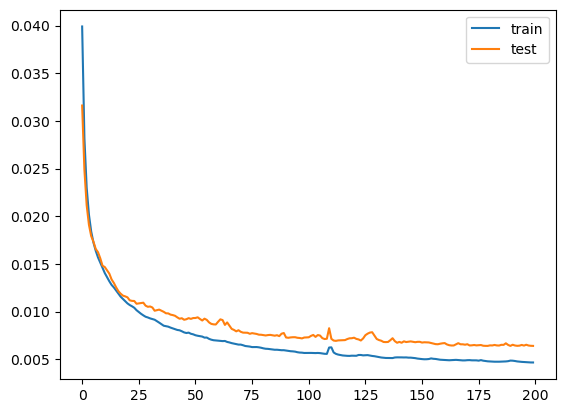

In [22]:
# Plot training results
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.legend()
plt.show()

In [23]:
torch.save(model.state_dict(), 'autoencoder.pth')

In [24]:
model = AE.AutoEncoderSmall(n_inputs, n_bottleneck).to(device)
model.load_state_dict(torch.load('autoencoder.pth'))
model

AutoEncoderSmall(
  (encoder): Sequential(
    (0): Linear(in_features=20000, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=128, out_features=100, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=256, out_features=20000, bias=True)
  )
)

In [25]:
X_col_tensor = torch.tensor(X_col_2d, dtype=torch.float32).to(device)
X_encoded = model.encode(X_col_tensor)
X_encoded

tensor([[-3.2513,  1.8134, -1.8404,  ...,  0.7623, -2.6987, -1.5215],
        [-3.2513,  1.8134, -1.8404,  ...,  0.7623, -2.6987, -1.5215],
        [-3.2513,  1.8134, -1.8404,  ...,  0.7623, -2.6987, -1.5215],
        ...,
        [-3.2513,  1.8134, -1.8404,  ...,  0.7623, -2.6987, -1.5215],
        [-3.2513,  1.8134, -1.8404,  ...,  0.7623, -2.6987, -1.5215],
        [-3.2513,  1.8134, -1.8404,  ...,  0.7623, -2.6987, -1.5215]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [26]:
print(sum(X_col_2d[0]))
print(sum(X_col_2d[1]))
print(sum(X_col_2d[2]))
print(sum(X_col_2d[3]))
print(sum(X_col_2d[4]))
print(sum(X_col_2d[5]))
print(sum(X_col_2d[6]))

0.0
0.0
0.0
0.0
1602.0
584.0
0.0


In [27]:
X_encoded_np = X_encoded.cpu().detach().numpy()
print(X_encoded_np)
print(type(X_encoded_np))
print(X_encoded_np.shape)

[[-3.2513375   1.813395   -1.8404021  ...  0.76229614 -2.6986687
  -1.5214555 ]
 [-3.2513375   1.813395   -1.8404021  ...  0.76229614 -2.6986687
  -1.5214555 ]
 [-3.2513375   1.813395   -1.8404021  ...  0.76229614 -2.6986687
  -1.5214555 ]
 ...
 [-3.2513375   1.813395   -1.8404021  ...  0.76229614 -2.6986687
  -1.5214555 ]
 [-3.2513375   1.813395   -1.8404021  ...  0.76229614 -2.6986687
  -1.5214555 ]
 [-3.2513375   1.813395   -1.8404021  ...  0.76229614 -2.6986687
  -1.5214555 ]]
<class 'numpy.ndarray'>
(22154, 100)


In [28]:
print(sum(X_encoded_np[0]))
print(sum(X_encoded_np[1]))
print(sum(X_encoded_np[2]))
print(sum(X_encoded_np[3]))
print(sum(X_encoded_np[4]))
print(sum(X_encoded_np[5]))
print(sum(X_encoded_np[6]))

13.632863599807024
13.632863599807024
13.632863599807024
13.632863599807024
6.678709656000137
11.799050875008106
13.632863599807024


In [29]:
all_features

index,gene_id,all_features,value_1
u32,str,list[f64],f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [30]:
X_encoded_pl = pl.from_numpy(X_encoded_np, schema=["all_features_encoded"])

In [31]:
X_encoded_pl

all_features_encoded
"array[f32, 100]"
"[-3.251338, 1.813395, … -1.521456]"
"[-3.251338, 1.813395, … -1.521456]"
"[-3.251338, 1.813395, … -1.521456]"
"[-3.251338, 1.813395, … -1.521456]"
"[-3.396299, 1.772281, … -0.591376]"
…
"[-3.251338, 1.813395, … -1.521456]"
"[-3.251338, 1.813395, … -1.521456]"
"[-3.251338, 1.813395, … -1.521456]"


In [32]:
all_features

index,gene_id,all_features,value_1
u32,str,list[f64],f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [33]:
# Concatenate the new column horizontally
af_encoded = pl.concat([all_features, X_encoded_pl], how='horizontal')

In [34]:
af_encoded

index,gene_id,all_features,value_1,all_features_encoded
u32,str,list[f64],f64,"array[f32, 100]"
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"[-3.251338, 1.813395, … -1.521456]"
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0,"[-3.251338, 1.813395, … -1.521456]"
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452,"[-3.251338, 1.813395, … -1.521456]"
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743,"[-3.251338, 1.813395, … -1.521456]"
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934,"[-3.396299, 1.772281, … -0.591376]"
…,…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0,"[-3.251338, 1.813395, … -1.521456]"
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0,"[-3.251338, 1.813395, … -1.521456]"
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0,"[-3.251338, 1.813395, … -1.521456]"


In [35]:
af_encoded_np = af_encoded.to_numpy()

In [36]:
af_encoded_np[0]

array([0, 'XLOC_000001', array([0., 0., 0., ..., 0., 0., 0.]), 0.0,
       array([-3.2513375e+00,  1.8133950e+00, -1.8404021e+00, -7.9316515e-01,
              -1.1735467e+00,  1.8265321e+00, -7.5312704e-01, -3.7598974e-01,
               4.3282932e-01,  3.6956649e+00,  1.9690250e+00,  1.8706182e+00,
              -4.2324386e+00, -4.7488439e-01,  3.4765210e+00,  1.3819700e+00,
              -1.2451757e+00,  1.1925007e+00,  1.5226064e+00,  4.5760860e+00,
               2.9176605e+00, -2.6920867e-01, -2.5465024e-01,  1.2433562e-02,
              -2.5836987e+00,  1.1425084e+00, -1.9668282e+00,  9.9705780e-01,
              -3.9048684e-01, -7.2996628e-01, -5.2366674e-01, -8.9998007e-01,
               1.8278942e+00,  4.5250076e-01,  1.0726101e+00, -4.8031359e+00,
              -8.2356048e-01, -1.2814268e+00,  1.0695149e+00, -1.1266929e+00,
               3.2263041e+00,  8.5338092e-01,  1.8143733e+00, -4.6718736e+00,
               2.9810803e+00, -2.5250156e+00, -4.4944100e-02,  8.3425462e-

In [37]:
# Split train, test, validation by index
data_indices = np.arange(len(af_encoded_np))
print(data_indices)

[    0     1     2 ... 22151 22152 22153]


In [38]:
# First split: 80% train, 20% temporary (for test + validation)
train_idx, temp_idx = train_test_split(
    data_indices, 
    test_size=0.2, 
    random_state=42  # For reproducibility
)

In [39]:
# Second split: Split temp_idx into 50% test and 50% validation
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.5, 
    random_state=42  # Same random_state for consistency
)

In [40]:
print(train_idx)
print(val_idx)
print(test_idx)

[12829 12333  8225 ...  5390   860 15795]
[13202 15153  3113 ...  1158  6603 15289]
[17261  8344  1396 ...  7985   482 16493]


In [41]:
# Result: train_idx (80%), test_idx (10%), val_idx (10%)
print(f"Train indices: {len(train_idx)}")
print(f"Test indices: {len(test_idx)}")
print(f"Validation indices: {len(val_idx)}")

Train indices: 17723
Test indices: 2216
Validation indices: 2215


In [42]:
# Define the dataset
train_dataset = HG2D.HepG2DatasetAutoEncoder(int(0.8 * NUM_ITEMS), af_encoded_np, train_idx)
val_dataset = HG2D.HepG2DatasetAutoEncoder(int(0.1 * NUM_ITEMS), af_encoded_np, val_idx)
test_dataset = HG2D.HepG2DatasetAutoEncoder(int(0.1 * NUM_ITEMS), af_encoded_np, test_idx)

In [43]:
# Define the dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [44]:
# Initialize the model
model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

# Define learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

In [45]:
print(model)

BinaryClassifierDropOutL1L2(
  (network): Sequential(
    (0): Linear(in_features=200, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [46]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [47]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")
else:
    START_EPOCH = 0

In [48]:
# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Training phase
    for X_batch, y_batch in train_loader:

        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs.squeeze(1) >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(device)).sum().item()
        train_total += y_batch.size(0)
        
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
        
    # # Adjust learning rate
    # scheduler.step()
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            
            if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
                outputs = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
            elif MODEL_MODE == "dol1l2":
                outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))

    # Adjust learning rate
    scheduler.step(val_loss)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')
    
    # Save the model
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_aucs': train_aucs,
        'val_aucs': val_aucs,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'val_f1_scores': val_f1_scores,
    }, CHECKPOINT_NAME)

Epoch [1/200] - [TRAIN] Loss: 0.7152, Accuracy: 55.82%, AUC: 0.55 [VAL] Loss: 0.6904, Accuracy: 63.86%, Precision: 0.69, Recall: 0.43, F1-Score: 0.53, AUC: 0.63
Epoch [2/200] - [TRAIN] Loss: 0.6762, Accuracy: 63.18%, AUC: 0.63 [VAL] Loss: 0.6545, Accuracy: 68.77%, Precision: 0.71, Recall: 0.58, F1-Score: 0.64, AUC: 0.68
Epoch [3/200] - [TRAIN] Loss: 0.6518, Accuracy: 66.38%, AUC: 0.66 [VAL] Loss: 0.6316, Accuracy: 69.16%, Precision: 0.70, Recall: 0.60, F1-Score: 0.65, AUC: 0.69
Epoch [4/200] - [TRAIN] Loss: 0.6371, Accuracy: 67.61%, AUC: 0.67 [VAL] Loss: 0.6206, Accuracy: 69.33%, Precision: 0.68, Recall: 0.64, F1-Score: 0.66, AUC: 0.69
Epoch [5/200] - [TRAIN] Loss: 0.6287, Accuracy: 68.12%, AUC: 0.68 [VAL] Loss: 0.6180, Accuracy: 69.11%, Precision: 0.68, Recall: 0.64, F1-Score: 0.66, AUC: 0.69
Epoch [6/200] - [TRAIN] Loss: 0.6218, Accuracy: 68.59%, AUC: 0.68 [VAL] Loss: 0.6135, Accuracy: 68.99%, Precision: 0.68, Recall: 0.64, F1-Score: 0.66, AUC: 0.69
Epoch [7/200] - [TRAIN] Loss: 0.61

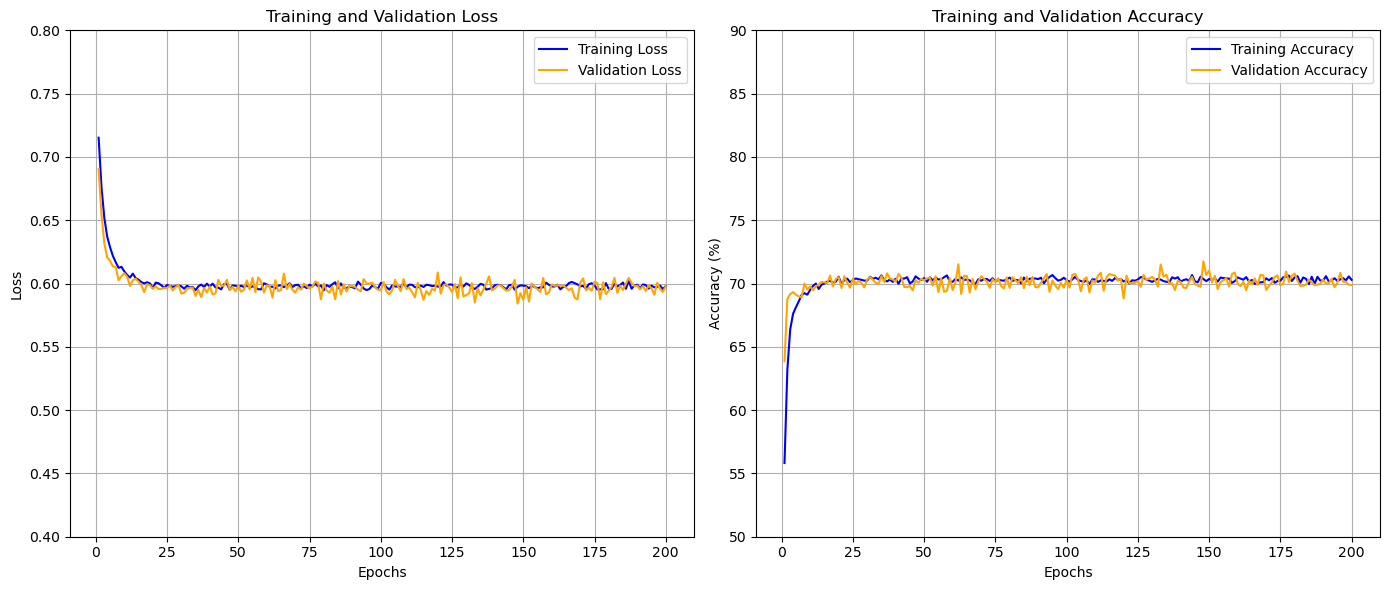

In [49]:
# Plot metrics
my_util.plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS, IMAGE_FILE)

In [50]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, _, _ = model(X_batch.to(dtype=torch.float32).to(device))
        
        predictions = (outputs.squeeze(1) >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [51]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
cr = classification_report(test_true_labels, test_predictions)
cm = confusion_matrix(test_true_labels, test_predictions)

In [52]:
test_output = f"""Accuracy Score on test set: {test_acc_score:.2f} %
AUC Score on test set: {test_auc_score:.2f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-Score: {f1_score:.4f}

Detailed Classification Report:
{cr}

Confusion Matrix:
{cm}
"""

print(test_output)

Accuracy Score on test set: 70.10 %
AUC Score on test set: 0.70
Precision: 0.7010
Recall: 0.6519
F1-Score: 0.6756

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.75      0.72      5225
           1       0.70      0.65      0.68      4775

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000


Confusion Matrix:
[[3897 1328]
 [1662 3113]]



In [53]:
# Save the test output to text file
with open(TEST_FILE, 'w', newline = '') as text_file:
    text_file.write(test_output)

In [54]:
# Training metrics
experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)
experiment_pl.write_csv(TRAINING_FILE)

In [55]:
# Test output
test_results = {
    'test_acc'    : round(test_acc_score, 4),
    'test_auc'    : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(TEST_RESULT_FILE)

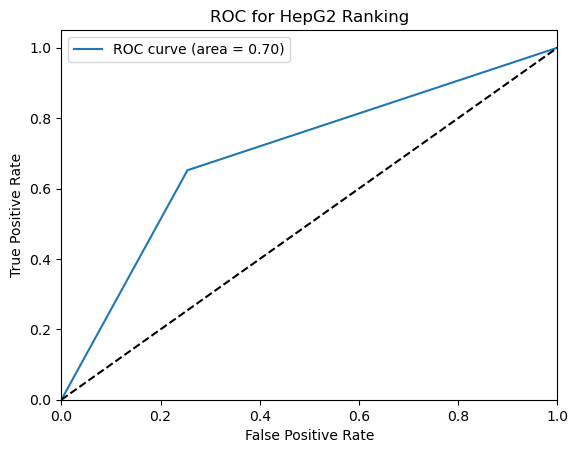

In [56]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Ranking')
plt.legend()

plt.savefig(ROC_FILE)

plt.show()

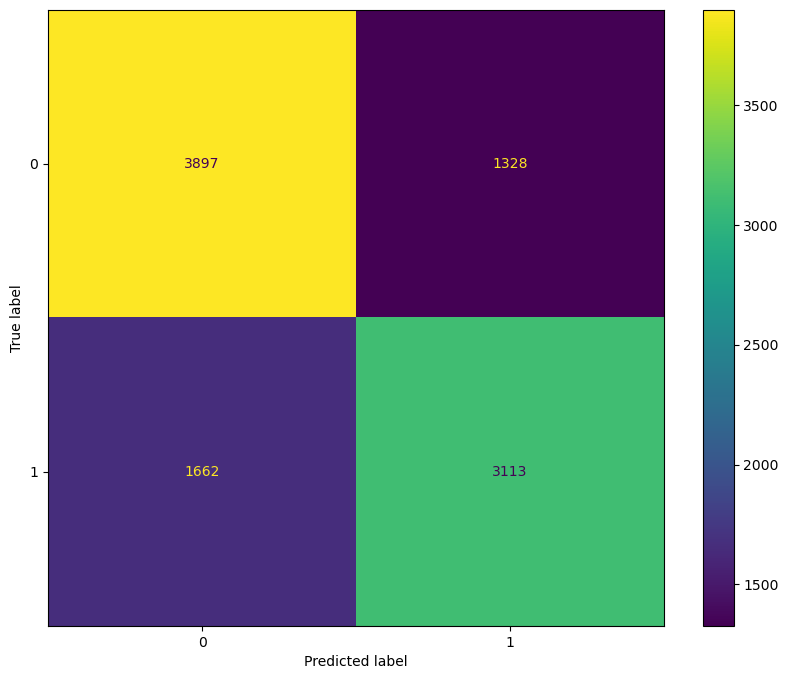

In [57]:
# Plot the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
cm_display.plot(ax=ax)
plt.savefig(CM_FILE)